<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U2-T1-V4.2-Recomendação não personalizada</b></h2>


---

# Exemplo 1 - Recomendação não personalizada - Listas Top-10

Existem diversos conjuntos de dados disponíveis para pesquisa em sistemas de recomendação. Dentre eles, o conjunto de dados **MovieLens** é provavelmente um dos mais populares.

Os dados do dataset **MovieLens** foram coletados de um sistema de recomendação de filmes não comercial disponível na web no endereço [MovieLens](https://movielens.org/), que foi criado em 1997 e administrado pelo GroupLens, um laboratório de pesquisa da Universidade de Minnesota, a fim de coletar dados de classificação de filmes para fins de pesquisa.



Os arquivos de dados **MovieLens** podem ser encontrados no site [GroupLens](https://grouplens.org/datasets/movielens/).

##Download dos arquivos

In [62]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [63]:
import numpy as np
import pandas as pd
import os, ssl
import seaborn as sns

def check_ssl():
    if (not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None)):
        ssl._create_default_https_context = ssl._create_unverified_context

# Download MovieLens data.
print("Fazendo o download dos dados...")
from urllib.request import urlretrieve
import zipfile

check_ssl()
urlretrieve("https://files.grouplens.org/datasets/movielens/ml-latest-small.zip", "movielens.zip")
zip_ref = zipfile.ZipFile('movielens.zip', "r")
zip_ref.extractall()

print("Concluído.")

Fazendo o download dos dados...
Concluído.


##Preparação de dados e análise exploratória

####Arquivo de filmes

In [64]:
movies = pd.read_csv('ml-latest-small/movies.csv', header=0, encoding='latin-1', low_memory=False)
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [65]:
movies.shape

(9742, 3)

####Arquivo de classificações (*ratings*)

In [66]:
ratings = pd.read_csv('ml-latest-small/ratings.csv', header=0, encoding='latin-1', low_memory=False)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [67]:
ratings.shape

(100836, 4)

In [68]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [69]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


####Descobrir o total de votos e de classificações por filme

In [70]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [71]:
movrat = ratings.groupby('movieId').agg(vote_count=('rating', 'count'), vote_average=('rating', 'mean'))
movrat.head()

,vote_count,vote_average
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


In [72]:
movrat[['vote_count','vote_average']].mean()

,0
vote_count,10.369807
vote_average,3.262448


Incorporar as features de classificação

In [73]:
movies = movies.merge(movrat, left_index=True, right_index=True)
movies.head()

,movieId,title,genres,vote_count,vote_average
1,2,Jumanji (1995),Adventure|Children|Fantasy,215,3.920930
2,3,Grumpier Old Men (1995),Comedy|Romance,110,3.431818
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,52,3.259615
4,5,Father of the Bride Part II (1995),Comedy,7,2.357143
5,6,Heat (1995),Action|Crime|Thriller,49,3.071429


## Recomendação simples

###Top-10 filmes mais votados

In [74]:
colunas = ['title', 'genres', 'vote_count', 'vote_average']

movies[colunas].sort_values(by=['vote_count', 'vote_average'], ascending=[False, False]).head(10)

,title,genres,vote_count,vote_average
356,"Age of Innocence, The (1993)",Drama,329,4.164134
318,I Love Trouble (1994),Action|Comedy,317,4.429022
296,Virtuosity (1995),Action|Sci-Fi|Thriller,307,4.197068
593,Cemetery Man (Dellamorte Dellamore) (1994),Horror,279,4.161290
2571,Teenage Mutant Ninja Turtles II: The Secret of...,Action|Children|Fantasy,278,4.192446
260,Quiz Show (1994),Drama,251,4.231076
480,Terminal Velocity (1994),Action|Mystery|Thriller,238,3.750000
110,Jupiter's Wife (1994),Documentary,237,4.031646
589,Last Dance (1996),Drama,224,3.970982
527,"Aristocats, The (1970)",Animation|Children,220,4.225000


###Top-10 filmes melhores classificados

In [75]:
movies[colunas].sort_values(by=['vote_average','vote_count'], ascending=[False, False]).head(10)

,title,genres,vote_count,vote_average
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,2,5.0
99,Rumble in the Bronx (Hont faan kui) (1995),Action|Adventure|Comedy|Crime,2,5.0
1151,Temptress Moon (Feng Yue) (1996),Romance,2,5.0
3473,Happy Accidents (2000),Romance|Sci-Fi,2,5.0
6442,Premonition (2007),Drama|Fantasy|Mystery|Thriller,2,5.0
6818,Red Cliff (Chi bi) (2008),Action|Adventure|Drama|War,2,5.0
148,Living in Oblivion (1995),Comedy,1,5.0
467,Shadowlands (1993),Drama|Romance,1,5.0
495,"Ciao, Professore! (Io speriamo che me la cavo)...",Drama,1,5.0
496,Spanking the Monkey (1994),Comedy|Drama,1,5.0


**Atenção**:

Observe acima que os filmes com maior classificação tiveram ***poucas avaliações***.



Efeito da loja recém-cadastrada no iFood

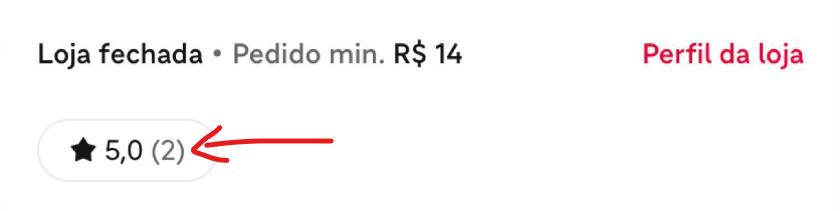

###Top-10 filmes melhores classificados (pelo menos 20 votos)

Filtrar filmes com pelo menos 20 votos

<br>

**Atenção**:

Observe que existem ainda algumas pequenas variações entre o total de classificações

In [76]:
movies[ movies['vote_count'] > 20 ][colunas] \
    .sort_values(by=['vote_average','vote_count'], ascending=[False, False]) \
    .head(10)

,title,genres,vote_count,vote_average
318,I Love Trouble (1994),Action|Comedy,317,4.429022
922,"Godfather: Part II, The (1974)",Crime|Drama,27,4.333333
898,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,29,4.310345
1204,Leave It to Beaver (1997),Comedy,45,4.300000
475,Son in Law (1993),Comedy|Drama|Romance,25,4.300000
246,New York Cop (NyÃ» YÃ´ku no koppu) (1993),Action|Crime,29,4.293103
858,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller,192,4.289062
1235,I Know What You Did Last Summer (1997),Horror|Mystery|Thriller,26,4.288462
2959,Billy Elliot (2000),Drama,218,4.272936
1276,Amistad (1997),Drama|Mystery,57,4.271930


###Top-10 filmes melhores classificados (classificação balanceada)

Para amenizar estas situações, o [IMDb](https://www.imdb.com/chart/top/?ref_=nv_mv_250) utiliza uma classificação ponderada para balancear o total de votos e a classificação, como pode ser visto na fórmula abaixo:
<br><br>

$$Weighted Rating = \left( \frac{v}{v+m} \right) \times R +  \left( \frac{m}{v+m} \right) \times C$$

Onde,

* $R$ = classificação média do filme (`vote_average`)

* $v$ = número de votos do filme (`vote_count`)

* $m$ = número mínimo de votos a considerar

* $C$ = classificação média de todos os filmes


Se o mínimo a ser considerado $m$ for zero, o valor será exatamente a classificação média do filme $R$.

In [77]:
movies['vote_count'].describe()

,vote_count
count,5390.000000
mean,14.459926
std,27.771290
min,1.000000
25%,2.000000
50%,4.000000
75%,14.000000
max,329.000000


Para o número mínimo de votos a considerar, variável $m$, geralmente é utilizado o percentil 75, que considera o mínimo de votos dos ***25% dos filmes mais votados***.

In [78]:
# Pegar a quantidade mínima de votos dos filmes com mais votos que 75% dos filmes

m = movies['vote_count'].quantile(0.75)
m

np.float64(14.0)

In [79]:
print('Total:',movies.shape[0])
print('75%:',movies[ movies['vote_count'] < m].shape[0])
print('25%:',movies[ movies['vote_count'] >= m].shape[0])

Total: 5390
75%: 4040
25%: 1350


Computar a classificação média geral de todos os filmes, variável $C$

In [80]:
ratings['rating'].mean()

np.float64(3.501556983616962)

In [81]:
movies['vote_average'].mean()

np.float64(3.2393540659517583)

In [82]:
# Computar o C - classificação média geral de todos os filmes
C = movies['vote_average'].mean()
C

np.float64(3.2393540659517583)

Calcular o ***IMDb weighted rating*** e armazenar em uma nova coluna `score`

In [83]:
# Calcular o 'IMDB weighted rating' para cada filme

import math

MIN_RATING = 0.0
MAX_RATING = float(math.ceil(ratings.rating.max()))

print(MIN_RATING, MAX_RATING)

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']

    # Compute the weighted score
    return (v/(v+m) * R) + (m/(m+v) * C)

movies['imdb_score'] = movies.apply(weighted_rating, axis=1)

0.0 5.0


**Atenção**:

Observe como o novo `imdb_score` equilibra a classificação com o total de votos

In [84]:
colunas = ['title', 'genres', 'vote_count', 'vote_average', 'imdb_score']
movies[colunas].head(10)

,title,genres,vote_count,vote_average,imdb_score
1,Jumanji (1995),Adventure|Children|Fantasy,215,3.920930,3.879262
2,Grumpier Old Men (1995),Comedy|Romance,110,3.431818,3.410088
3,Waiting to Exhale (1995),Comedy|Drama|Romance,52,3.259615,3.255318
4,Father of the Bride Part II (1995),Comedy,7,2.357143,2.945284
5,Heat (1995),Action|Crime|Thriller,49,3.071429,3.108745
6,Sabrina (1995),Comedy|Romance,102,3.946078,3.860784
7,Tom and Huck (1995),Adventure|Children,54,3.185185,3.196338
8,Sudden Death (1995),Action,8,2.875000,3.106862
9,GoldenEye (1995),Action|Adventure|Thriller,16,3.125000,3.178365
10,"American President, The (1995)",Comedy|Drama|Romance,132,3.496212,3.471582


In [85]:
movies[colunas].tail(10)

,title,genres,vote_count,vote_average,imdb_score
8984,Joe Dirt 2: Beautiful Loser (2015),Comedy,43,3.290698,3.278087
8985,Return to Treasure Island (1988),Adventure|Animation|Comedy,14,2.857143,3.048248
8987,Dark Places (2015),Drama|Mystery|Thriller,1,3.000000,3.223397
8989,Massu Engira Maasilamani (2015),Comedy|Horror|Thriller,1,3.500000,3.256730
8998,Before We Go (2014),Romance,1,4.000000,3.290064
9004,Always Watching: A Marble Hornets Story (2015),Horror,1,2.000000,3.156730
9005,Madly in Love (1981),Comedy,2,2.000000,3.084435
9008,Love (2015),Drama|Romance,1,2.500000,3.190064
9010,The Runner (2015),Drama,5,4.100000,3.465840
9018,"Visit, The (2015)",Comedy|Horror,3,4.333333,3.432409


Ordenação das melhores avaliados

In [86]:
movies[colunas].sort_values(by=['vote_average', 'vote_count'], ascending=False).head(10)

,title,genres,vote_count,vote_average,imdb_score
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,2,5.0,3.459435
99,Rumble in the Bronx (Hont faan kui) (1995),Action|Adventure|Comedy|Crime,2,5.0,3.459435
1151,Temptress Moon (Feng Yue) (1996),Romance,2,5.0,3.459435
3473,Happy Accidents (2000),Romance|Sci-Fi,2,5.0,3.459435
6442,Premonition (2007),Drama|Fantasy|Mystery|Thriller,2,5.0,3.459435
6818,Red Cliff (Chi bi) (2008),Action|Adventure|Drama|War,2,5.0,3.459435
148,Living in Oblivion (1995),Comedy,1,5.0,3.356730
467,Shadowlands (1993),Drama|Romance,1,5.0,3.356730
495,"Ciao, Professore! (Io speriamo che me la cavo)...",Drama,1,5.0,3.356730
496,Spanking the Monkey (1994),Comedy|Drama,1,5.0,3.356730


Ordenação dos melhores avaliados pelo IMDB score

In [87]:
movies[colunas].sort_values(by=['imdb_score', 'vote_count'], ascending=False).head(10)

,title,genres,vote_count,vote_average,imdb_score
318,I Love Trouble (1994),Action|Comedy,317,4.429022,4.378704
858,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller,192,4.289062,4.217723
2959,Billy Elliot (2000),Drama,218,4.272936,4.210564
260,Quiz Show (1994),Drama,251,4.231076,4.178683
50,Georgia (1995),Drama,204,4.237745,4.173628
527,"Aristocats, The (1970)",Animation|Children,220,4.225000,4.166030
1221,Soul Food (1997),Drama,129,4.259690,4.159797
296,Virtuosity (1995),Action|Sci-Fi|Thriller,307,4.197068,4.155299
1196,Picture Perfect (1997),Comedy|Romance,211,4.215640,4.154893
1213,"Kiss Me, Guido (1997)",Comedy,126,4.250000,4.148935


# Exemplo 2 - Recomendação não personalizada - Cesta de Mercado

### Carga de dados

In [88]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1MPaam9K1ByMB_EFp_zy3LYvK5UqQVeM5')
df = df.drop(df.loc[df['Item']=='Não Especificado'].index)
df.tail()

,Data,Hora,Transacao,Item
21288,2017-04-09,14:32:58,9682,Café
21289,2017-04-09,14:32:58,9682,Chá
21290,2017-04-09,14:57:06,9683,Café
21291,2017-04-09,14:57:06,9683,Massa Folhada
21292,2017-04-09,15:04:24,9684,Vitaminas


### Gerar itens frequentes

In [89]:
lst = []
for item in df['Transacao'].unique():
    lst2 = list(set(df[df['Transacao']==item]['Item']))
    if len(lst2)>0:
        lst.append(lst2)
print(lst[0:3])


[['Pão'], ['Pão Escandinavo'], ['Geleia', 'Biscoitos', 'Chocolate Quente']]


Instalar biblioteca para encontrar os conjuntos de itens e as regras de associação

In [90]:
!pip install -q mlxtend

In [92]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [93]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_data = te.fit(lst).transform(lst)
data_x = pd.DataFrame(te_data,columns=te.columns_)
data_x.head()


,Ajuste,Alfajores,Bacon,Baguete,Bandeja de Arte,Banquete Vegano,Batatas Fritas,Biscoito Infantil,Biscoitos,Bolo,...,Tartine,Tiffin,Tigela Nic Pitt,Torrada,Torta Bakewell,Trufas,Vale-presente,Vitaminas,Xarope de Gengibre,Água Mineral
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [94]:
frequent_items= apriori(data_x, use_colnames=True, min_support=0.002)
print('Total de itens:',len(frequent_items))
frequent_items.head()

Total de itens: 260


,support,itemsets
0,0.036344,(Alfajores)
1,0.016059,(Baguete)
2,0.004015,(Bandeja de Arte)
3,0.054411,(Biscoitos)
4,0.103856,(Bolo)


### Gerar regras de associação

In [95]:
rules = association_rules(frequent_items, metric="lift", min_threshold=2)
print(f'Foram descobertas {len(rules)} regras')
rules.sort_values(['lift','confidence'], ascending=[False,False]).head(10)


Foram descobertas 62 regras


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12,(Geleia),(Doce de Leite Cremoso),0.015003,0.015003,0.002536,0.169014,11.265622,1.0,0.002311,1.185336,0.925114,0.092308,0.156357,0.169014
13,(Doce de Leite Cremoso),(Geleia),0.015003,0.015003,0.002536,0.169014,11.265622,1.0,0.002311,1.185336,0.925114,0.092308,0.156357,0.169014
48,(Brunch Espanhol),"(Café, Suco)",0.018172,0.020602,0.002007,0.110465,5.361807,1.0,0.001633,1.101022,0.828552,0.054598,0.091753,0.103951
47,"(Café, Suco)",(Brunch Espanhol),0.020602,0.018172,0.002007,0.097436,5.361807,1.0,0.001633,1.087821,0.830608,0.054598,0.080731,0.103951
46,"(Brunch Espanhol, Café)",(Suco),0.010882,0.038563,0.002007,0.184466,4.783482,1.0,0.001588,1.178905,0.799649,0.042316,0.151755,0.118260
49,(Suco),"(Brunch Espanhol, Café)",0.038563,0.010882,0.002007,0.052055,4.783482,1.0,0.001588,1.043434,0.822672,0.042316,0.041626,0.118260
51,"(Café, Coca-Cola)",(Sanduíche),0.006445,0.071844,0.002007,0.311475,4.335463,1.0,0.001544,1.348037,0.774335,0.026316,0.258180,0.169708
52,(Sanduíche),"(Café, Coca-Cola)",0.071844,0.006445,0.002007,0.027941,4.335463,1.0,0.001544,1.022114,0.828895,0.026316,0.021636,0.169708
17,(Jammie Dodgers),(Suco),0.013207,0.038563,0.002113,0.160000,4.149041,1.0,0.001604,1.144568,0.769138,0.042553,0.126308,0.107397
16,(Suco),(Jammie Dodgers),0.038563,0.013207,0.002113,0.054795,4.149041,1.0,0.001604,1.043999,0.789423,0.042553,0.042145,0.107397


### Gerar recomendações

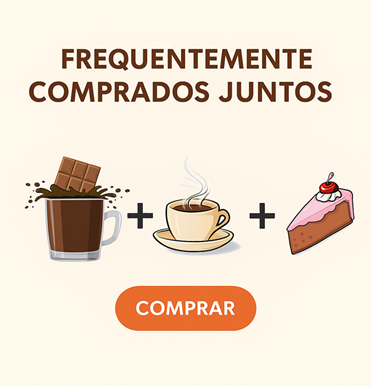

In [96]:
def get_recommendations(antecedents, rules, top=5):
    if type(antecedents) != list: antecedents = [antecedents]
    #preds = rules[rules['antecedents'].apply(lambda x: all(item in x for item in antecedents))]\
    preds = rules[rules['antecedents'].apply(lambda x: all(item in x for item in antecedents) and (len(x)==len(antecedents)))]\
            .sort_values(['lift','confidence'], ascending =[False, False])
    result = set()
    #result = { i for c in preds['consequents'] for i in c if i not in antecedents and len(result) < top }
    for c in preds['consequents']:
        for i in c:
            if i not in antecedents:
                result.add(i)
        if len(result) >= top:
            break
    return list(result)[:top]


get_recommendations(['Chocolate Quente'], rules)


['Bolo', 'Biscoitos', 'Brownie', 'Café']

In [97]:
get_recommendations(['Sanduíche'], rules, top=2)

['Café', 'Coca-Cola']

In [98]:
get_recommendations(['Sanduíche'], rules, top=5)

['Trufas', 'Sopa', 'Água Mineral', 'Coca-Cola', 'Café']

In [99]:
get_recommendations(['Café','Sopa'], rules, top=2)

['Sanduíche']

In [100]:
get_recommendations(['Geleia'], rules, top=2)

['Doce de Leite Cremoso']